In [1]:
import torch
from torch import nn # contains all the blocks for neural networks
import matplotlib.pyplot as plt



In [2]:
'''
Preparing and loading Data 
Create known parameters

'''

#inputs 

weight = 0.7 
bias = 0.3


#Create Data 
start = 0
end = 1
step = 0.02
X = torch.arange (start, end, step).unsqueeze(dim=1) #unsqueeze adds extra dimensions. 
                                                     #Try removing the unsqueeze to see the results
                                                     
#output
y = weight * X + bias

# Debugging

#X[:10], y[:10] 
#slen(X), len(y) 

In [3]:
'''

Spliting data into training and test sets (The #1 thing to take into account when managing data)

Total data = 50

Create a train/test split

'''

train_split = int(0.8 *len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

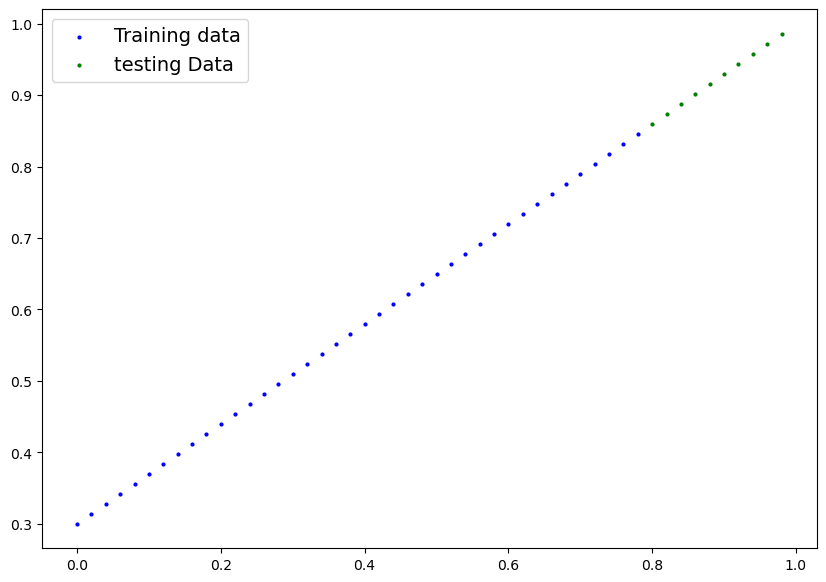

In [14]:
def plot_prediction (train_data =X_train, 
                     train_labels = y_train,
                     test_data = X_test,
                     test_label = y_test,
                     predictions = None) :
    
    plt.figure (figsize= (10, 7))
    
    #Plot training data
    plt.scatter(train_data, train_labels, c ="b", s=4, label = "Training data")
    
    #Plot test data
    plt.scatter(test_data, test_label, c="g", s =4 , label="testing Data")
    
    
    #R there predictions
    if predictions is not None:
        plt.scatter(test_data, predictions, c='r', label = "predictions")
    
    plt.legend(prop ={"size" :14})
    
plot_prediction()

## Build Models 

Check for more information: 
1. Gradient Descent
2. Backpropagation 

*Both are implemented to improve our models*

In [9]:
# Create a linear regression modal class 

class LinearRegressionModel(nn.Module):  # <- Hereda de nn.Module
    def __init__(self):
        super().__init__()
        
        # Inicializar los parámetros del modelo
        self.weight = nn.Parameter(torch.randn(1, 
                                               requires_grad=True,  # Requiere gradiente
                                               dtype=torch.float))  # float32 por defecto
        self.bias = nn.Parameter(torch.randn(1, 
                                             requires_grad=True,  # Para descenso por gradiente
                                             dtype=torch.float))
        
    # Método forward define la operación del modelo
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weight * x + self.bias  # Esta es la ecuación de regresión lineal

        
         

#### Pytorch model building essentials

* torch.nn : contains all buildings for compuitational neural networks
* torch.nn.parameter: Parameters should our model try and learn
* torch.nn.Module : Base class for all neural network modules, you should write a forward function
* torch.optim : where the optimizers in Pytorch live, they help gradient descent 
* def foward () : All nn.Module subclasses requieres Forward function


In [ ]:
#To check whats inside of our neural network

# Create a random seed 
torch.manual_seed(42) #TO get reproducable results

#Create instance of our model 
model_0 = LinearRegressionModel()

#Check out paramters
list(model_0.parameters())

#List name parameters
weight, bias 

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

#### Making predictions using *torch.inference_mode()* 

To check our model's prediction, we must see how it predicts  y_test and X_test

When we pass data through our mordel, it going to run through the Forward method

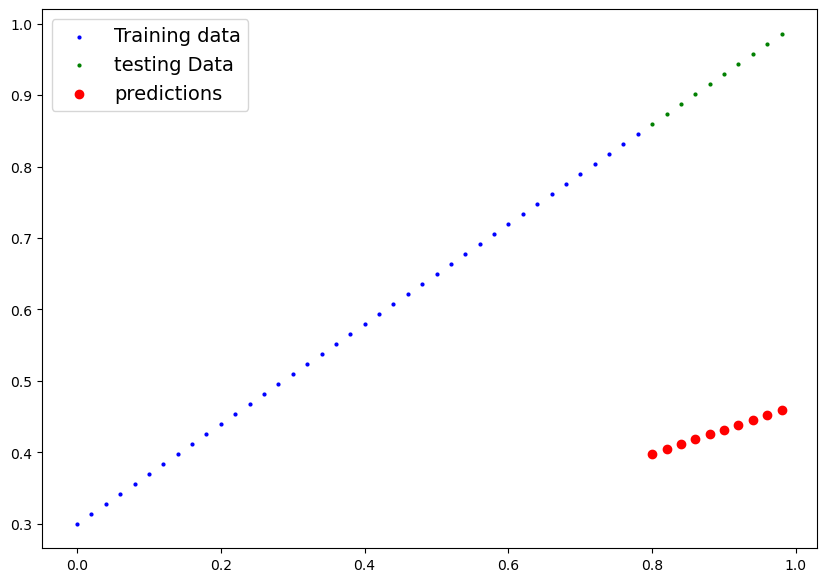

In [ ]:
'''
Make predictions
Note that these results will be terrible
'''
with torch.inference_mode():
    y_preds = model_0(X_test)
    
y_preds

y_test

plot_prediction(predictions=y_preds)

#### 3. Train Model

The idea of training is for a model to go from *unknown* parameters to *known* paramters 

Or from a poor representation of the data to a better representation

To measure how bad your prediction are is using loss function

To train models : 
1.  **Loss Function** : Function to measure how wrong your predictions are to your ideal model
2. **optimizer** : Takes into account the loss and adjust the model parameters to improve loss function

For pytorch: 
* training loop
* Testing loop

In [18]:

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
#Set up a loss function

loss_fn = nn.L1Loss()


#Set up an optimizer (Stochastic gradient descent. For ViT they used Adam)
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr = 0.01,) #learning rate is the most important hyperparameter (we set it)


### Building a training and testing loop

We need : 
0. Loop through the data
1. Forward pass  
2. Calculate the loss
3. Optimizer zero grad 
4. Loss backward - move backwards through the network to calculate the gradients of the parameters with respect to the loss (**backpropagation**)
5. Optimizer step - Improve the loss (**gradient descent**)


In [ ]:
# An epoch is one loop through data 

epochs = 1

## Training
# 0 . Loop through the data
for epoch in epochs ():
    # set the model to training mode 
    model_0.train() #train mode in pythorch set all parameters that requiere gradients to requiere gradients
    
    #1. Foward pass
    y_pred = model_0(X_train)
    
    #2. Calculate loss
    loss = loss_fn(y_pred, y_train) #(input, target)
    
    #3. Optimizer Zero Grad
    optimizer.zero_grad() #Restarts the value that the optimizer uses. 
    
    #4. Perfor backpropagation on the loss with respect with the parameters of the model
    loss.backward()
    
    #5. Step the optimizer - Perform gradient descent
    optimizer.step() 
    
    #model_0.eval() #turns off gradient tracking
    
    
    
    
    
    